# Day 13: End-to-End Machine Learning Toy Project

## 1. Introduction & Project Architecture
This notebook demonstrates a step-by-step implementation of an end-to-end Machine Learning classification pipeline using a toy dataset (`placement.csv`). The objective is to build a model that predicts whether a student gets placed based on their **CGPA** and **IQ**.

### The 8 Steps of the ML Lifecycle Covered Here:
1. Data Collection / Ingestion
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Train-Test Split
6. Feature Scaling
7. Model Training & Evaluation
8. Model Deployment via Serialization

## 2. Environment Setup & Data Ingestion

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install mlxtend

# Load the dataset
df = pd.read_csv('placements.csv')

# Inspect data dimensions and structure
print("Data Shape:", df.shape)
df.head()

Data Shape: (100, 4)


,RandomID,IQ,CGPA,Placement
0,71615,92,6.43,1
1,68564,94,7.84,1
2,59689,105,6.02,0
3,20742,92,6.31,0
4,63459,132,6.30,0


## 3. Data Preprocessing

In [7]:
# Check for missing data
df.info()

# Drop the redundant first column
df = df.iloc[:, 1:]
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   RandomID   100 non-null    int64  
 1   IQ         100 non-null    int64  
 2   CGPA       100 non-null    float64
 3   Placement  100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


,IQ,CGPA,Placement
0,92,6.43,1
1,94,7.84,1
2,105,6.02,0
3,92,6.31,0
4,132,6.30,0


## 4. Exploratory Data Analysis (EDA)

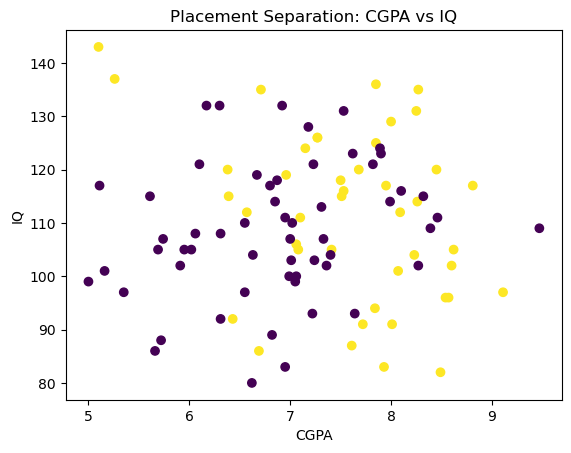

In [8]:
# Visualize relationships between features colored by placement status
plt.scatter(df['CGPA'], df['IQ'], c=df['Placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Placement Separation: CGPA vs IQ')
plt.show()

## 5. Feature Selection (Splitting Input and Output)

In [9]:
# Split independent variables (X) and dependent variable (y)
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (100, 2)
y Shape: (100,)


## 6. Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

# Perform 90% Training and 10% Testing Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## 7. Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and scale training data
X_train = scaler.fit_transform(X_train)

# Transform testing data using training parameters
X_test = scaler.transform(X_test)

## 8. Model Training & Evaluation

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Instantiate and train the model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predict on evaluation set
y_pred = clf.predict(X_test)

# Output final performance metric
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Accuracy Score: 80.00%


### Plotting Decision Boundary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 12.1 MB/s  0:00:002.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 2.2 MB/s  0:00:03 eta 0:00:010:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━━━━━━━ 0/3 [scikit-learn]
    Found existing installation: matplotlib 3.10.6 0/3 [scikit-learn]
    Uninstalling matplotlib-3.10.6:━━━━━━━━━━━━━━━ 0/3 [scikit-learn]
      Successfully uninstalled matplotlib-3.10.6m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mlxtend]━━━━━━━━━━ 2/3 [mlxtend]


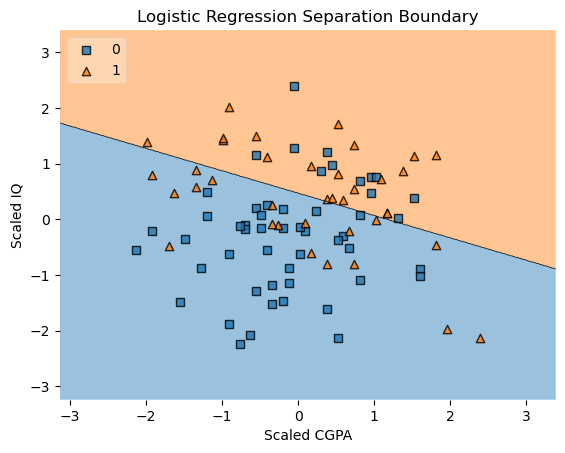

In [14]:

from mlxtend.plotting import plot_decision_regions

# Plot model classification boundary
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)
plt.xlabel('Scaled CGPA')
plt.ylabel('Scaled IQ')
plt.title('Logistic Regression Separation Boundary')
plt.show()

## 9. Model Serialization for Deployment

In [16]:
import pickle

# Save trained model file
with open('model.pkl', 'wb') as f:
    pickle.dump(clf, f)

# Save scaler configurations
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)